# Clasificación morfológica Madrid H3 — v5 (Método 1 **unsupervised** + Método 2 RF)

Dos métodos sobre el mismo conjunto de 42 métricas (caché `master_hex_v4.gpkg`):

- **Método 1 — Índice teórico no supervisado.** A cada variable se le impone un **signo teórico**
  (+1 = valor alto → espontáneo; −1 = alto → planificado) por conocimiento urbano, **sin usar etiquetas**.
  Se estandariza cada variable (z-score sobre la ciudad) y el índice es la media de (signo × z). La
  partición se hace sin etiquetas (mezcla gaussiana de 2 componentes, o umbral por prior de proporción).
  Las etiquetas se usan **solo para validar** (AUC, F1) a posteriori.
- **Método 2 — Random Forest supervisado** (benchmark de precisión, `class_weight=None`).

El índice no es un clasificador exacto, sino un **score morfológico transparente y reproducible**.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt, matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from pathlib import Path
plt.rcParams['figure.dpi'] = 120

BASE   = Path(r'C:\Users\Alvar\OneDrive\Desktop\estudios\economía\Artículos\MQUEA')
MASTER = BASE / 'clasificacion_morfologica' / 'master_hex_v4.gpkg'
LABELS = BASE / 'labels_hex_manual (5).csv'
GPKG_OUT = BASE / 'madrid_clasificacion_final_v5.gpkg'
CRS = 'EPSG:25830'
MIN_BLD = 5            # hexágono urbano si cat_n_buildings >= 5
PRIOR_ESP = 0.18       # prior suave de proporción espontánea (NO etiquetas) para el corte por percentil
P_LOW, P_HIGH = 0.40, 0.60   # banda del RF (Método 2)

# ── SIGNOS TEÓRICOS (+1 alto->espontáneo, -1 alto->planificado) — fijados por teoría, no por los datos
# grid_crystallinity_all / _major se EXCLUYEN: son copias bit a bit de R4_all / R4_major.
# Incluirlas hacía que el índice de media simple contase esas dos variables por duplicado,
# de modo que el peso ni siquiera era uniforme. Quedan 27 variables con signo teórico.
SIGN = {
    # red viaria / orientación
    'bearing_entropy':+1,'mean_circuity':+1,'p90_circuity':+1,'internal_connect':+1,'intersection_dens':+1,
    'edge_len_std':+1,'ADI_mean_all':+1,'ADI_median_all':+1,
    # forma de huella / manzana
    'cat_orientation_entropy':+1,'cat_perimeter_density':+1,'cat_footprint_ratio':+1,'area_local_cv':+1,'block_area_cv':+1,
    # época
    'cat_year_iqr':+1,'cat_pct_pre1860':+1,
    # planificado (-1)
    'dead_end_ratio':-1,'cat_floors_mean':-1,'cat_far':-1,'cat_pct_post1985':-1,'cat_year_median':-1,
    'R4_all':-1,'BAS_all':-1,'BAS_major':-1,'R4_major':-1,
    'edgeR4':-1,'rectangularity':-1,'angle_align':-1,
}
print('Config OK ·', len(SIGN), 'variables con signo teórico')

Config OK · 29 variables con signo teórico


## 1. Cargar hexágonos (features) y etiquetas (solo para validar)

In [2]:
g = gpd.read_file(MASTER).to_crs(CRS)
lab = pd.read_csv(LABELS); lab['hex_id'] = lab['hex_id'].astype(str)
g['label'] = g['hex_id'].astype(str).map(dict(zip(lab['hex_id'], pd.to_numeric(lab['tipologia_train'], errors='coerce'))))
g['urban'] = pd.to_numeric(g['cat_n_buildings'], errors='coerce').fillna(0) >= MIN_BLD
print(f'Hexágonos: {len(g)} · urbanos: {int(g.urban.sum())} · etiquetados: {int(g.label.isin([0,1]).sum())}')

Hexágonos: 2887 · urbanos: 1654 · etiquetados: 733


## 2. Método 1 — Índice teórico **no supervisado**

z-score de cada variable sobre la ciudad (urbanos), índice = media de (signo × z). **No** entra ninguna etiqueta.

In [3]:
V = [v for v in SIGN if v in g.columns]
Z = pd.DataFrame(index=g.index)
for v in V:
    c = pd.to_numeric(g[v], errors='coerce'); mu, sd = c[g.urban].mean(), c[g.urban].std()
    Z[v] = SIGN[v] * (c - mu) / sd if sd and sd > 0 else 0.0
g['idx_espontaneo'] = Z[V].mean(axis=1)   # alto = espontáneo

# (a) partición automática: mezcla gaussiana de 2 componentes sobre el índice
xi = g.loc[g.urban, 'idx_espontaneo'].dropna().values.reshape(-1, 1)
gm = GaussianMixture(2, random_state=0).fit(xi)
hi = int(np.argmax(gm.means_.ravel()))     # componente de índice alto = espontáneo
g['idx_gmm'] = np.nan
mk = g.urban & g['idx_espontaneo'].notna()
g.loc[mk, 'idx_gmm'] = (gm.predict(g.loc[mk, 'idx_espontaneo'].values.reshape(-1, 1)) == hi).astype(int)

# (b) corte por prior de proporción (sin etiquetas): top PRIOR_ESP del índice = espontáneo
thr = g.loc[g.urban, 'idx_espontaneo'].quantile(1 - PRIOR_ESP)
g['tipologia_idx'] = np.where(g['idx_espontaneo'] >= thr, 'Espontáneo', 'Planificado')
g.loc[~g.urban, 'tipologia_idx'] = np.nan
print(f'Índice: {len(V)} variables')
print(f'  (a) GMM(2): espontáneo = {int((g.idx_gmm==1).sum())} ({(g.idx_gmm==1).sum()/g.urban.sum()*100:.0f}% urbano)')
print(f'  (b) prior {int(PRIOR_ESP*100)}% (idx>={thr:+.2f}): espontáneo = {int((g.tipologia_idx=="Espontáneo").sum())}')

Índice: 29 variables
  (a) GMM(2): espontáneo = 1171 (71% urbano)
  (b) prior 18% (idx>=+0.31): espontáneo = 298


## 3. Validación del índice (las etiquetas entran **solo aquí**)

In [4]:
m = g.label.isin([0,1])
yt = (g.loc[m,'label']==0).astype(int)     # 1 = espontáneo
auc = roc_auc_score(yt, g.loc[m,'idx_espontaneo'])
f1_gmm = f1_score(yt, g.loc[m,'idx_gmm'].fillna(0).astype(int), average='macro')
f1_pri = f1_score(yt, (g.loc[m,'tipologia_idx']=='Espontáneo').astype(int), average='macro')
print(f'AUC del índice (sin umbral): {auc:.3f}')
print(f'F1-macro · GMM: {f1_gmm:.3f}   ·   prior {int(PRIOR_ESP*100)}%: {f1_pri:.3f}')
print('\nÍndice medio por barrio (validación direccional):')
for b in ['Sol','Embajadores','Puerta del Ángel','Casco Histórico de Vallecas','Ensanche de Vallecas','Goya']:
    s = g[g['barrio_nombre']==b]
    if len(s): print(f'  {b:30s} idx={s.idx_espontaneo.mean():+.2f}')

AUC del índice (sin umbral): 0.766
F1-macro · GMM: 0.587   ·   prior 18%: 0.623

Índice medio por barrio (validación direccional):
  Sol                            idx=+0.61
  Embajadores                    idx=+0.42
  Puerta del Ángel               idx=+0.20
  Casco Histórico de Vallecas    idx=+0.15
  Ensanche de Vallecas           idx=-0.56
  Goya                           idx=-0.27


## 4. Mapa del índice (Método 1)

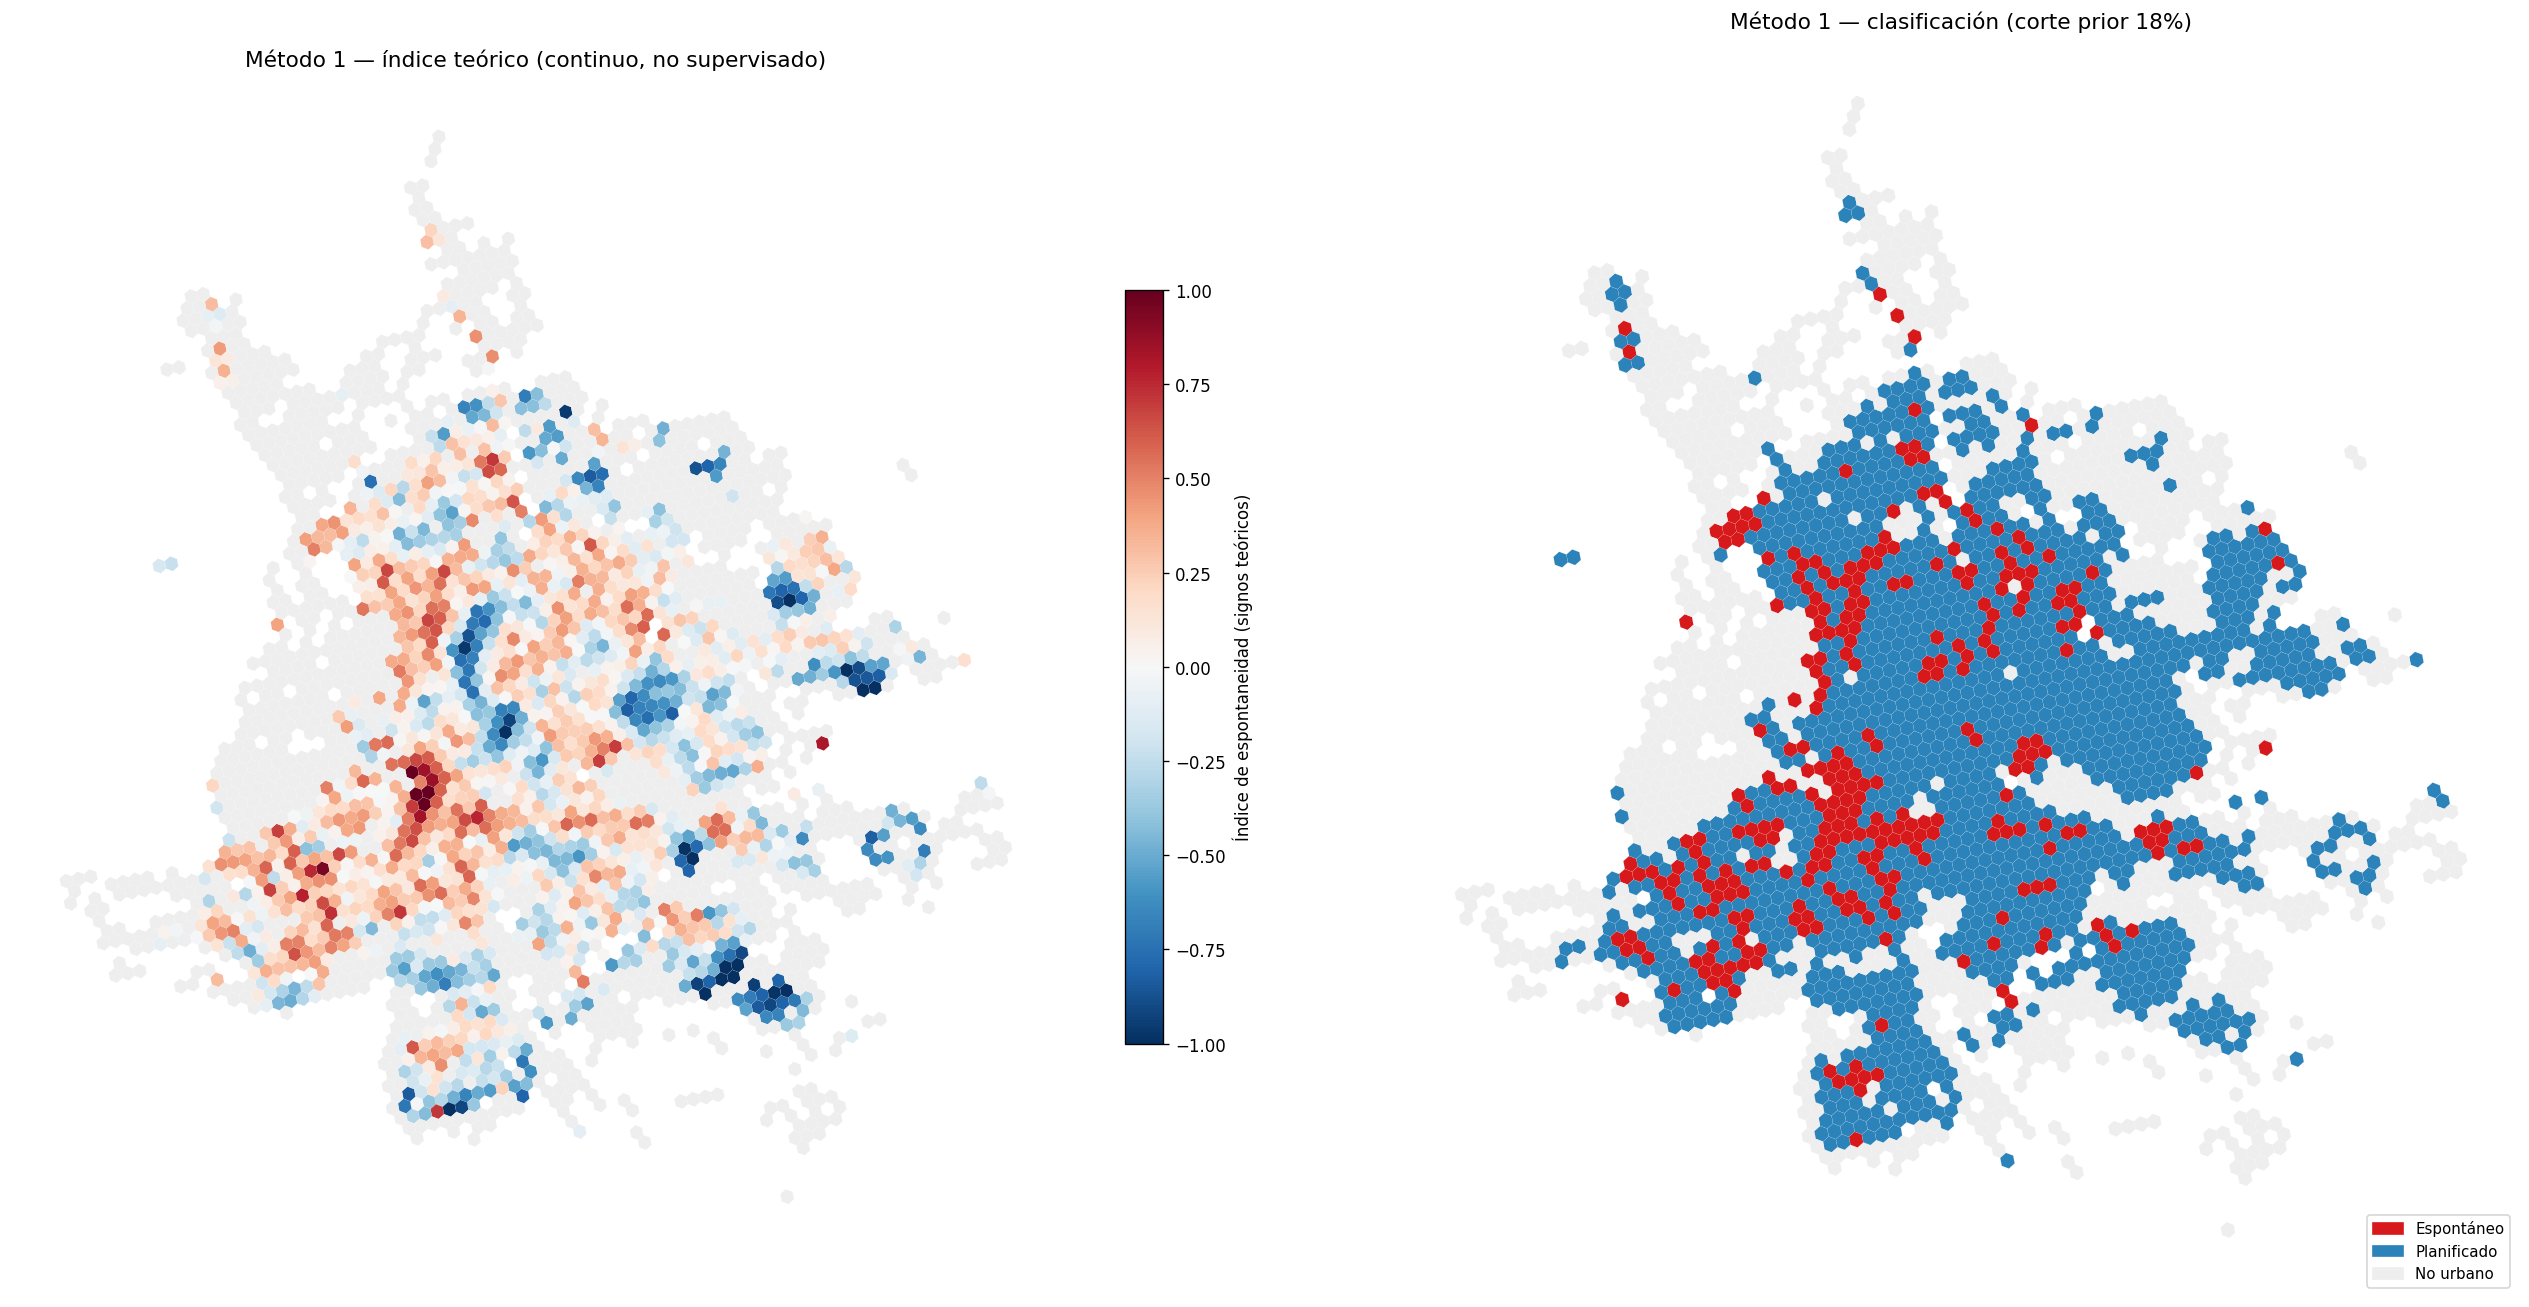

In [5]:
gp = g.copy(); gp.loc[~g.urban,'idx_espontaneo'] = np.nan
fig, ax = plt.subplots(1, 2, figsize=(22, 11))
gp.plot(column='idx_espontaneo', cmap='RdBu_r', legend=True, vmin=-1, vmax=1,
        legend_kwds={'label':'Índice de espontaneidad (signos teóricos)','shrink':0.6},
        ax=ax[0], linewidth=0.05, edgecolor='white', missing_kwds={'color':'#eeeeee'})
ax[0].set_title('Método 1 — índice teórico (continuo, no supervisado)', fontsize=13); ax[0].set_axis_off()
cidx = g['tipologia_idx'].map({'Espontáneo':'#d7191c','Planificado':'#2b83ba'}).fillna('#eeeeee')
g.plot(color=cidx, ax=ax[1], linewidth=0.05, edgecolor='white')
ax[1].legend(handles=[mpatches.Patch(color='#d7191c',label='Espontáneo'),mpatches.Patch(color='#2b83ba',label='Planificado'),
                      mpatches.Patch(color='#eeeeee',label='No urbano')], loc='lower right', fontsize=9)
ax[1].set_title(f'Método 1 — clasificación (corte prior {int(PRIOR_ESP*100)}%)', fontsize=13); ax[1].set_axis_off()
plt.tight_layout(); plt.show()

## 5. Método 2 — Random Forest supervisado (benchmark)

In [6]:
NET=['bearing_entropy','mean_circuity','p90_circuity','degree_std','edge_len_std','dead_end_ratio','intersection_dens','internal_connect','edge_len_mean','road_density_km','mean_degree']
ERA=['cat_pct_pre1860','cat_pct_1860_1940','cat_pct_1940_1960','cat_pct_1960_1985','cat_pct_post1985','cat_year_median','cat_year_iqr']
CVOL=['cat_floors_mean','cat_floors_cv','cat_far','cat_footprint_ratio','cat_pct_residential']
CFOOT=['cat_compactness_mean','cat_perimeter_density','cat_orientation_entropy']
DA=['R4_all','BAS_all','ADI_mean_all','ADI_median_all','R4_major','BAS_major','block_area_cv','block_compact_mean','grid_crystallinity_all','edge_len_cv_all','n_blocks','grid_crystallinity_major']
DB=['edgeR4','rectangularity','area_local_cv','angle_align']
FEATS=[f for f in NET+ERA+CVOL+CFOOT+DA+DB if f in g.columns]
mask=g.label.isin([0,1]); imp=SimpleImputer(strategy='median')
X=imp.fit_transform(g.loc[mask,FEATS]); y=g.loc[mask,'label'].astype(int).values
rf=RandomForestClassifier(n_estimators=400,max_features='sqrt',min_samples_leaf=3,class_weight=None,random_state=42,n_jobs=-1)
cv=cross_val_score(rf,X,y,cv=StratifiedKFold(5,shuffle=True,random_state=42),scoring='f1_macro')
rf.fit(X,y); g['p_esp']=rf.predict_proba(imp.transform(g[FEATS]))[:,0]
g['tipologia_rf']=np.select([g['p_esp']>=P_HIGH,g['p_esp']<=P_LOW],['Espontáneo','Planificado'],default='Transición')
g.loc[~g.urban,'tipologia_rf']=np.nan
print(f'RF CV F1-macro: {cv.mean():.3f} ± {cv.std():.3f}  ({len(FEATS)} variables)')
print('Tipología RF (urbano):', {k:int((g.loc[g.urban,"tipologia_rf"]==k).sum()) for k in ["Espontáneo","Transición","Planificado"]})

RF CV F1-macro: 0.847 ± 0.021  (42 variables)
Tipología RF (urbano): {'Espontáneo': 237, 'Transición': 133, 'Planificado': 1284}


## 6. Comparación Método 1 (índice) vs Método 2 (RF)

Acuerdo índice vs RF (urbano, RF no-transición): 79%
AUC índice: 0.766   |   RF CV F1: 0.847


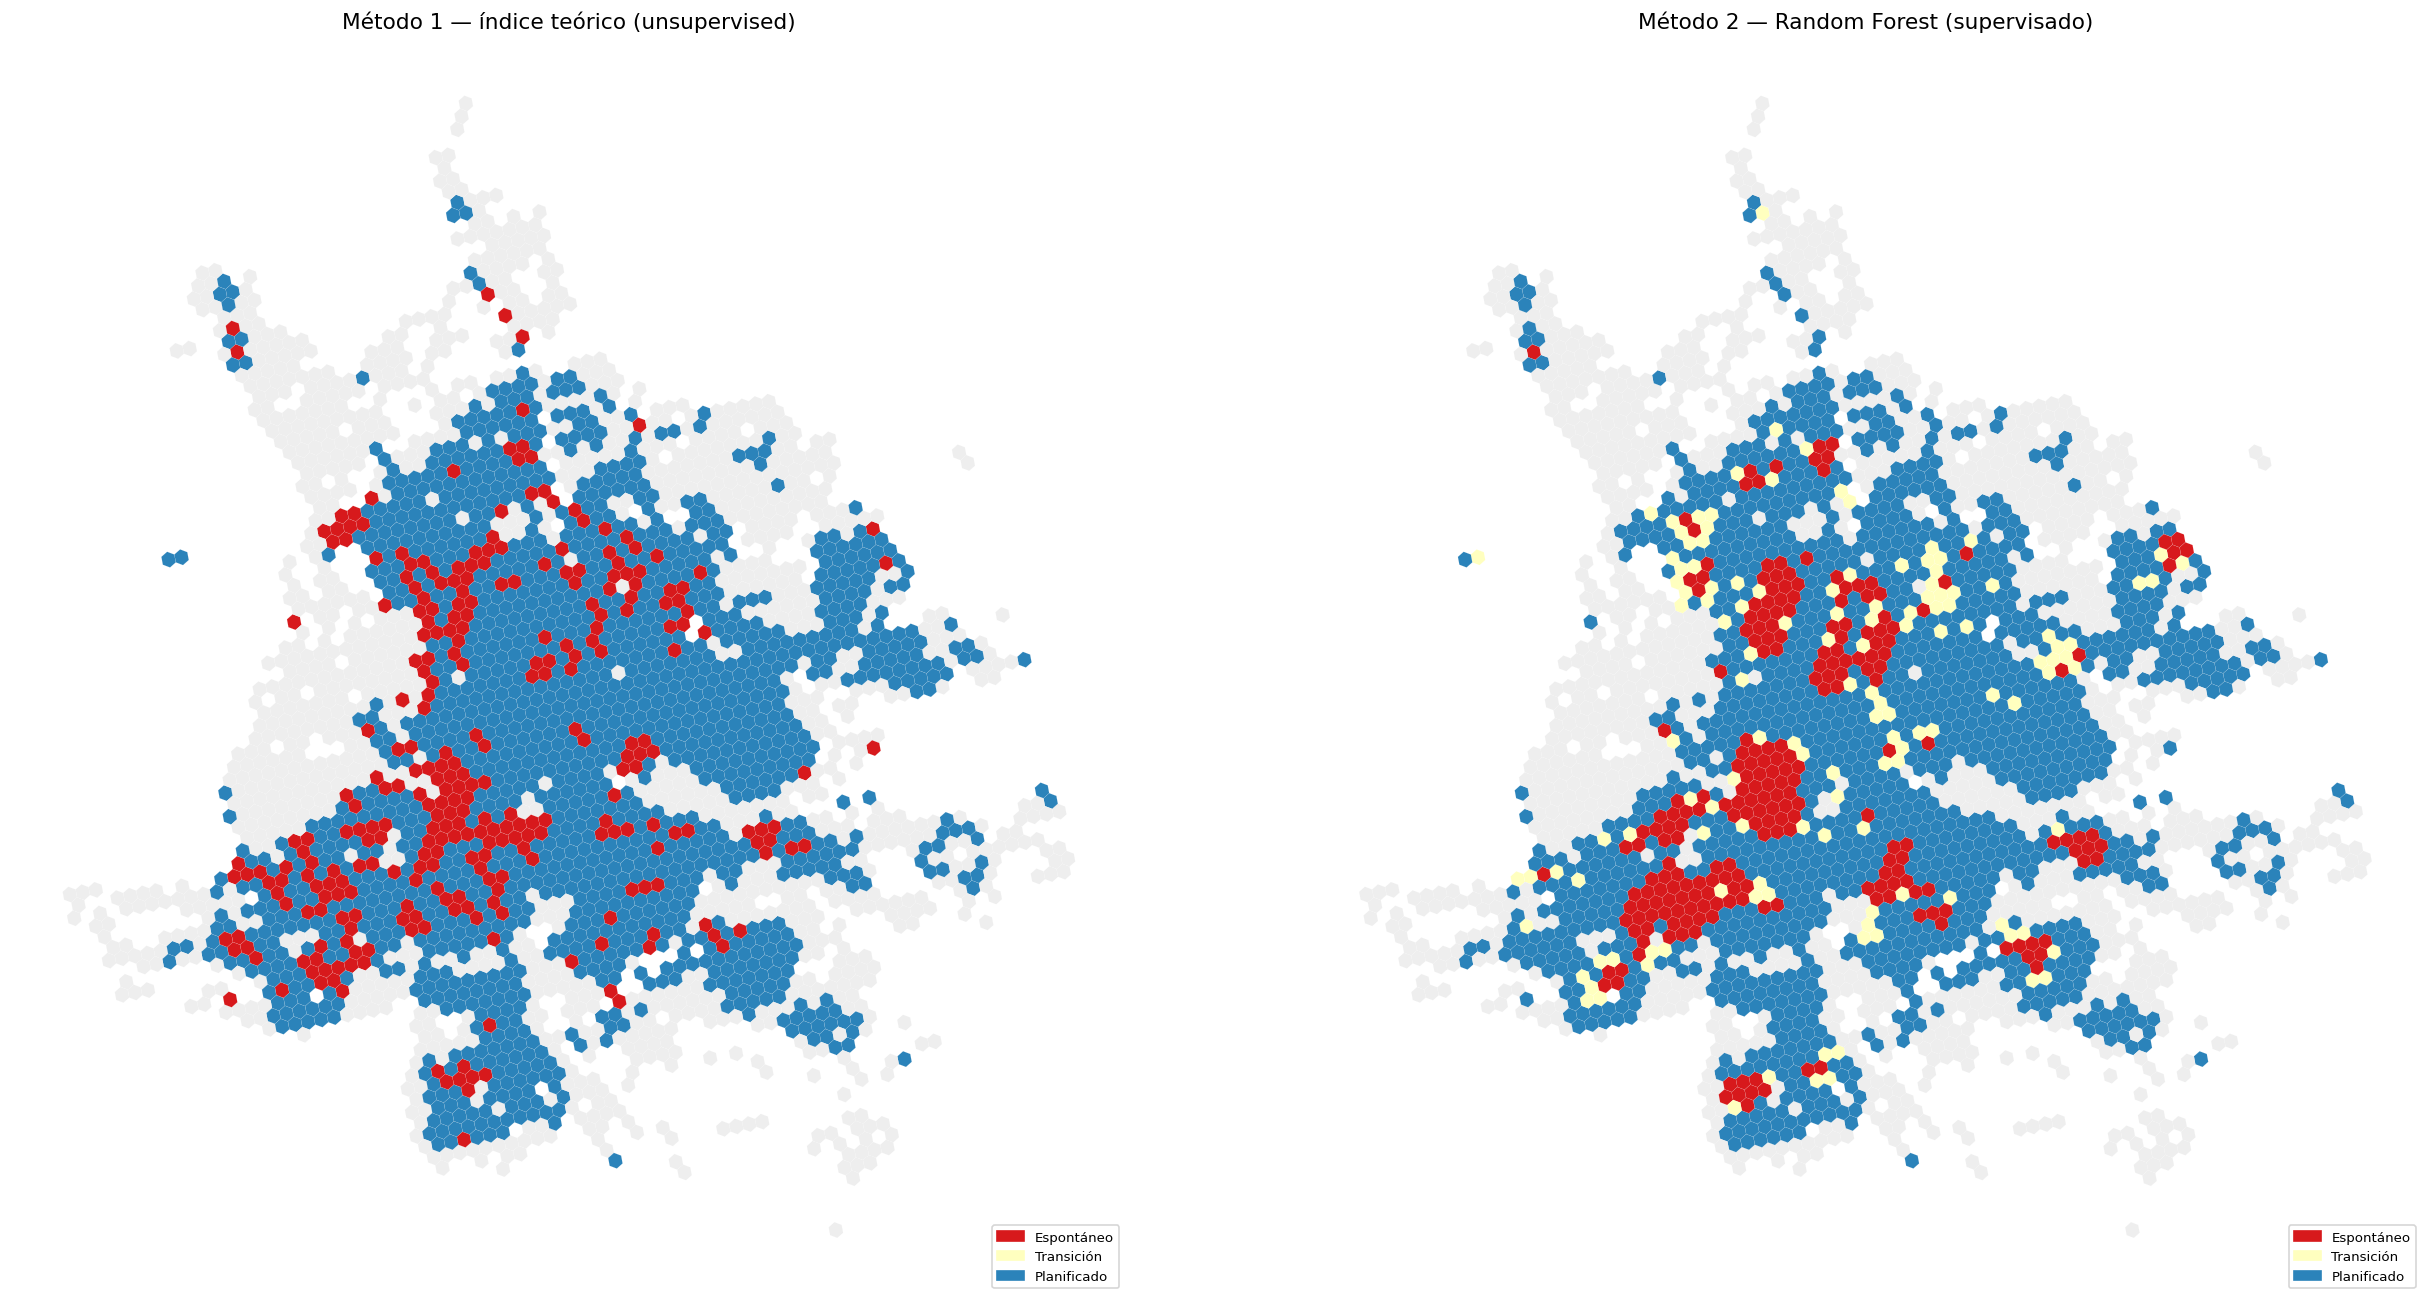

In [7]:
comp = g[g.urban & g['tipologia_idx'].notna() & g['tipologia_rf'].ne('Transición')].copy()
agree = (comp['tipologia_idx'] == comp['tipologia_rf']).mean()
print(f'Acuerdo índice vs RF (urbano, RF no-transición): {agree*100:.0f}%')
print(f'AUC índice: {auc:.3f}   |   RF CV F1: {cv.mean():.3f}')
fig, ax = plt.subplots(1, 2, figsize=(22, 11))
g.plot(color=g['tipologia_idx'].map({'Espontáneo':'#d7191c','Planificado':'#2b83ba'}).fillna('#eeeeee'), ax=ax[0], linewidth=0.05, edgecolor='white')
ax[0].set_title('Método 1 — índice teórico (unsupervised)', fontsize=13); ax[0].set_axis_off()
g.plot(color=g['tipologia_rf'].map({'Espontáneo':'#d7191c','Transición':'#ffffbf','Planificado':'#2b83ba'}).fillna('#eeeeee'), ax=ax[1], linewidth=0.05, edgecolor='white')
ax[1].set_title('Método 2 — Random Forest (supervisado)', fontsize=13); ax[1].set_axis_off()
for a in ax: a.legend(handles=[mpatches.Patch(color='#d7191c',label='Espontáneo'),mpatches.Patch(color='#ffffbf',label='Transición'),mpatches.Patch(color='#2b83ba',label='Planificado')],loc='lower right',fontsize=8)
plt.tight_layout(); plt.show()

## 7. Guardado

In [8]:
cols=[c for c in g.columns if c not in ['urban','centroid']]
g[cols].to_file(GPKG_OUT, driver='GPKG')
print('Guardado:', GPKG_OUT.name, '· columnas clave: idx_espontaneo, tipologia_idx, p_esp, tipologia_rf')

Guardado: madrid_clasificacion_final_v5.gpkg · columnas clave: idx_espontaneo, tipologia_idx, p_esp, tipologia_rf
